# Shopping Dataset Analysis & Insights

Exploratory Data Analysis (EDA), data cleaning, feature engineering, and category-level analysis on the e-commerce product dataset.

## Step 1: Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

df = pd.read_csv('../data/combined_dataset.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Column Names:")
print(df.columns.tolist())

Dataset Shape: 1000 rows, 24 columns

Column Names:
['product_id', 'title', 'product_description', 'rating', 'ratings_count', 'initial_price', 'discount', 'final_price', 'currency', 'images', 'delivery_options', 'product_details', 'breadcrumbs', 'product_specifications', 'amount_of_stars', 'what_customers_said', 'seller_name', 'sizes', 'videos', 'seller_information', 'variations', 'best_offer', 'more_offers', 'category']


In [2]:
df.head(3)

,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
0,8376765,Lino Perros,Women Navy Blue Solid Backpack,3.8,15,3995,58.0,"""₹3,995.00""",INR,http://assets.myntassets.com/assets/images/837...,...,"{""1_star"":2,""2_stars"":0,""3_stars"":3,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",NaN,[{}],{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
1,9136281,Tommy Hilfiger,Unisex Navy Blue Striped Backpack,4.5,67,2899,35.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/913...,...,"{""1_star"":3,""2_stars"":4,""3_stars"":2,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-9136281_cae700""]",NaN,"[{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
2,17633752,Lavie,Aries Women Pink Mini Backpack,4.4,226,2999,65.0,"""₹2,999.00""",INR,http://assets.myntassets.com/assets/images/176...,...,"{""1_star"":9,""2_stars"":5,""3_stars"":10,""4_stars""...",NaN,NaN,"[{""size"":""S""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,"[{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks


## Step 2: Understand Data

In [3]:
df.dtypes

product_id                  int64
title                         str
product_description           str
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                   str
currency                      str
images                        str
delivery_options              str
product_details               str
breadcrumbs                   str
product_specifications        str
amount_of_stars               str
what_customers_said           str
seller_name                   str
sizes                         str
videos                        str
seller_information            str
variations                    str
best_offer                    str
more_offers                   str
category                      str
dtype: object

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              1000 non-null   int64  
 1   title                   1000 non-null   str    
 2   product_description     1000 non-null   str    
 3   rating                  1000 non-null   float64
 4   ratings_count           1000 non-null   int64  
 5   initial_price           1000 non-null   int64  
 6   discount                879 non-null    float64
 7   final_price             1000 non-null   str    
 8   currency                1000 non-null   str    
 9   images                  1000 non-null   str    
 10  delivery_options        1000 non-null   str    
 11  product_details         1000 non-null   str    
 12  breadcrumbs             1000 non-null   str    
 13  product_specifications  1000 non-null   str    
 14  amount_of_stars         1000 non-null   str    
 15 

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,1000.0,NaN,NaN,NaN,17134372.582,3813765.757473,586846.0,15115009.5,18208901.0,19027372.0,22747068.0
title,1000,454,Roadster,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_description,1000,989,Women Pink Solid Top,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1000.0,NaN,NaN,NaN,3.6215,1.3744,0.0,3.7,4.1,4.3,5.0
ratings_count,1000.0,NaN,NaN,NaN,76.691,241.114263,0.0,7.0,17.0,58.0,4441.0
initial_price,1000.0,NaN,NaN,NaN,2723.241,2408.69736,249.0,1399.0,1999.0,3299.0,22199.0
discount,879.0,NaN,NaN,NaN,53.503982,18.029201,1.0,44.0,56.0,66.0,88.0
final_price,1000,466,"""₹999.00""",25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
currency,1000,1,INR,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
images,1000,1000,http://assets.myntassets.com/assets/images/837...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

discount               121
what_customers_said    573
seller_name            301
videos                 781
seller_information     301
variations             562
dtype: int64

## Step 3: Data Cleaning

In [7]:
# Clean price-related columns and convert to numeric format
df['final_price'] = (
    df['final_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace('"', '', regex=False)
    .str.strip()
)
df['final_price'] = pd.to_numeric(df['final_price'], errors='coerce')
df['initial_price'] = pd.to_numeric(df['initial_price'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')

# Impute missing discounts based on initial and final price
calc_discount = ((df['initial_price'] - df['final_price']) / df['initial_price'] * 100).round(2)
df['discount'] = df['discount'].fillna(calc_discount).fillna(0)

# Fill missing ratings and review counts
df['rating'] = df['rating'].fillna(df['rating'].median())
df['ratings_count'] = df['ratings_count'].fillna(0).astype(int)

# Remove duplicate products based on product_id
duplicates_count = df.duplicated(subset=['product_id']).sum()
df = df.drop_duplicates(subset=['product_id'], keep='first').copy()
print(f"Duplicates removed: {duplicates_count}")
print(f"Cleaned dataset shape: {df.shape}")

Duplicates removed: 0
Cleaned dataset shape: (1000, 24)


## Step 4: Feature Engineering

In [8]:
# Price difference between initial price and final price
df['price_difference'] = (df['initial_price'] - df['final_price']).clip(lower=0)

# Popularity metric using rating and log-scaled ratings count
df['popularity_metric'] = (df['rating'] * np.log1p(df['ratings_count'])).round(2)

# Effective discount percentage
df['savings_percentage'] = np.where(
    df['initial_price'] > 0,
    ((df['price_difference'] / df['initial_price']) * 100).round(2),
    0
)

df[['title', 'initial_price', 'final_price', 'price_difference', 'popularity_metric', 'savings_percentage']].head()

,title,initial_price,final_price,price_difference,popularity_metric,savings_percentage
0,Lino Perros,3995,3995.0,0.0,10.54,0.0
1,Tommy Hilfiger,2899,2899.0,0.0,18.99,0.0
2,Lavie,2999,2999.0,0.0,23.87,0.0
3,F Gear,1675,1675.0,0.0,30.62,0.0
4,MYTRIDENT,2899,2899.0,0.0,12.06,0.0


## Step 5: Analysis

### Univariate Analysis

In [9]:
df[['initial_price', 'final_price', 'price_difference', 'discount', 'rating', 'ratings_count', 'popularity_metric']].describe().T

,count,mean,std,min,25%,50%,75%,max
initial_price,1000.0,2723.24100,2408.697360,249.0,1399.00,1999.00,3299.00,22199.00
final_price,1000.0,1706.09600,1783.864472,199.0,649.00,1099.00,2082.25,17995.00
price_difference,1000.0,1017.14500,1393.966867,0.0,0.00,659.00,1476.25,14652.00
discount,1000.0,47.39506,23.879825,0.0,35.00,53.00,65.00,88.00
rating,1000.0,3.62150,1.374400,0.0,3.70,4.10,4.30,5.00
ratings_count,1000.0,76.69100,241.114263,0.0,7.00,17.00,58.00,4441.00
popularity_metric,1000.0,12.27717,6.944404,0.0,8.24,12.07,16.73,37.79


### Bivariate Analysis

In [10]:
corr_cols = ['initial_price', 'final_price', 'price_difference', 'discount', 'rating', 'ratings_count', 'popularity_metric']
correlation_matrix = df[corr_cols].corr()
correlation_matrix

,initial_price,final_price,price_difference,discount,rating,ratings_count,popularity_metric
initial_price,1.000000,0.819315,0.679464,0.081817,-0.081486,-0.023120,-0.075729
final_price,0.819315,1.000000,0.136028,-0.185970,0.084587,-0.030233,0.044909
price_difference,0.679464,0.136028,1.000000,0.379361,-0.249050,-0.001261,-0.188325
discount,0.081817,-0.185970,0.379361,1.000000,-0.181479,0.007153,-0.146675
rating,-0.081486,0.084587,-0.249050,-0.181479,1.000000,0.125795,0.679136
ratings_count,-0.023120,-0.030233,-0.001261,0.007153,0.125795,1.000000,0.535405
popularity_metric,-0.075729,0.044909,-0.188325,-0.146675,0.679136,0.535405,1.000000


### Category-level Analysis

In [11]:
category_stats = df.groupby('category').agg(
    total_products=('product_id', 'count'),
    mean_initial_price=('initial_price', 'mean'),
    mean_final_price=('final_price', 'mean'),
    mean_discount=('discount', 'mean'),
    mean_rating=('rating', 'mean'),
    total_reviews=('ratings_count', 'sum'),
    mean_popularity=('popularity_metric', 'mean')
).reset_index().sort_values(by='total_products', ascending=False)

category_stats.head(10)

,category,total_products,mean_initial_price,mean_final_price,mean_discount,mean_rating,total_reviews,mean_popularity
85,tops,122,1578.778689,1245.352459,47.942623,3.450000,5077,11.345164
23,dresses,100,2557.300000,1296.030000,54.130000,3.527000,15462,11.887500
73,shirts,97,2233.432990,1431.896907,50.216495,3.967010,6085,13.524330
47,jeans,57,3491.035088,2173.649123,47.228070,3.831579,4837,14.407368
77,sports-shoes,51,5570.686275,4228.470588,28.569804,4.117647,3243,14.549020
91,tshirts,39,1478.358974,1044.717949,42.923077,3.876923,4715,14.874103
27,earrings,34,2412.705882,746.441176,66.588235,2.864706,2574,9.559412
79,sweaters,34,2196.411765,1605.500000,40.529412,4.147059,3060,16.026471
46,jackets,29,4335.241379,2494.310345,46.965517,3.734483,2991,16.025862
15,casual-shoes,23,4566.608696,2660.782609,44.260870,3.221739,1031,10.979130


## Step 6: Visualization

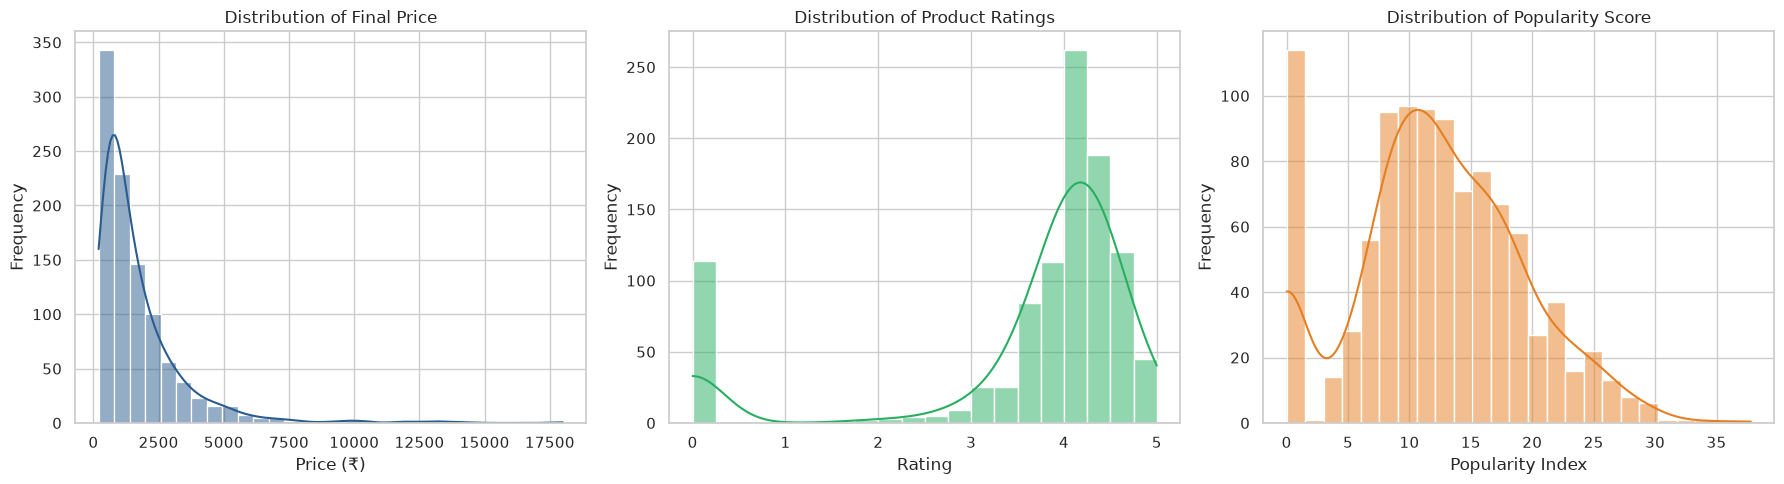

In [12]:
# Distribution of Final Price, Ratings, and Popularity Metric
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['final_price'], kde=True, ax=axes[0], color='#2b5c8f', bins=30)
axes[0].set_title('Distribution of Final Price')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['rating'], kde=True, ax=axes[1], color='#27ae60', bins=20)
axes[1].set_title('Distribution of Product Ratings')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Frequency')

sns.histplot(df['popularity_metric'], kde=True, ax=axes[2], color='#e67e22', bins=25)
axes[2].set_title('Distribution of Popularity Score')
axes[2].set_xlabel('Popularity Index')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

C:\Users\vs332\AppData\Local\Temp\ipykernel_26216\704304104.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pop_cats, x='mean_popularity', y='category', ax=axes[0], palette='Blues_r')
C:\Users\vs332\AppData\Local\Temp\ipykernel_26216\704304104.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_stats.head(10), x='total_products', y='category', ax=axes[1], palette='Purples_r')


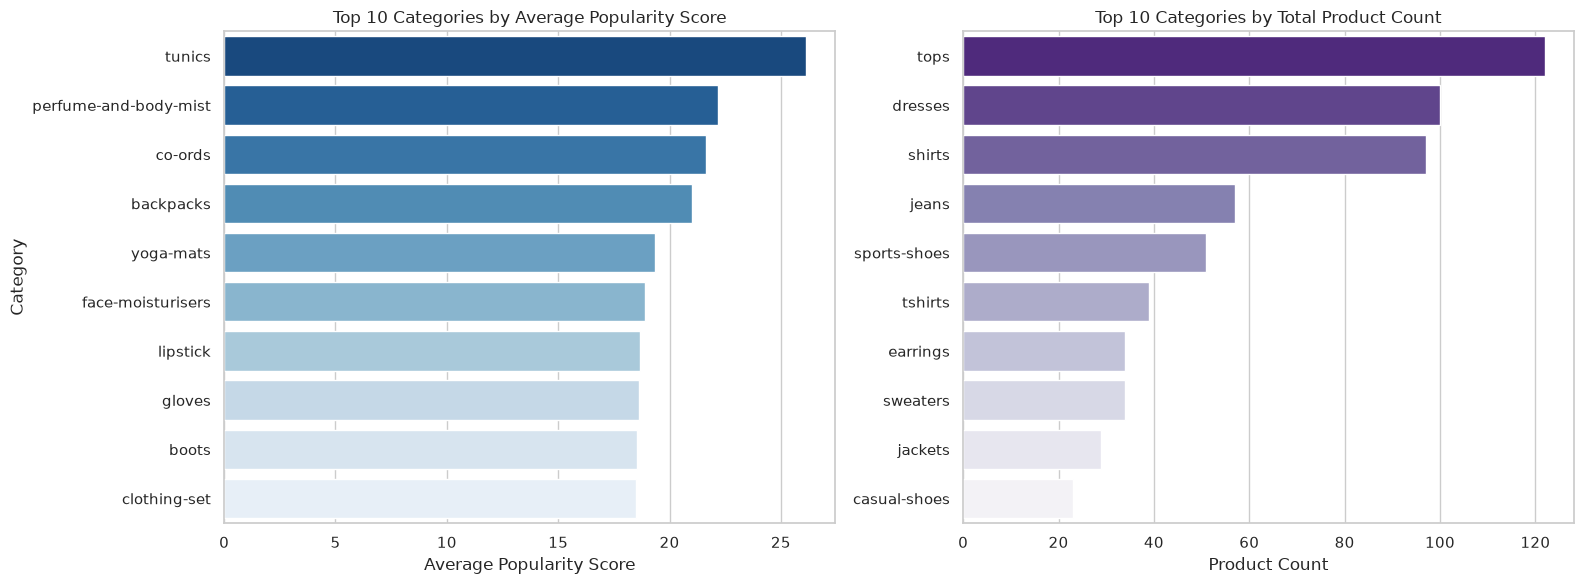

In [13]:
# Category Performance Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_pop_cats = category_stats.sort_values(by='mean_popularity', ascending=False).head(10)
sns.barplot(data=top_pop_cats, x='mean_popularity', y='category', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Categories by Average Popularity Score')
axes[0].set_xlabel('Average Popularity Score')
axes[0].set_ylabel('Category')

sns.barplot(data=category_stats.head(10), x='total_products', y='category', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top 10 Categories by Total Product Count')
axes[1].set_xlabel('Product Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\vs332\AppData\Local\Temp\ipykernel_26216\932513878.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_cat_df, x='final_price', y='category', ax=axes[0], palette='Set3')


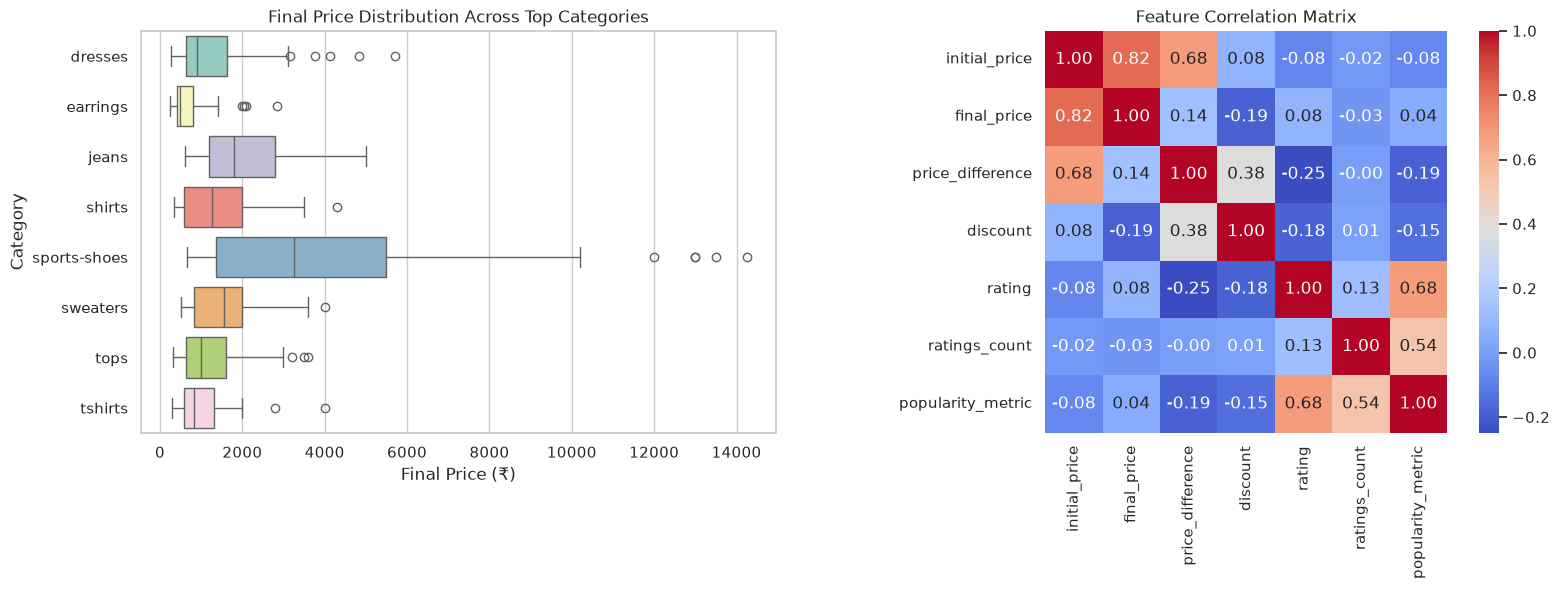

In [14]:
# Category Price Distribution and Correlation Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_categories = category_stats.head(8)['category']
top_cat_df = df[df['category'].isin(top_categories)]

sns.boxplot(data=top_cat_df, x='final_price', y='category', ax=axes[0], palette='Set3')
axes[0].set_title('Final Price Distribution Across Top Categories')
axes[0].set_xlabel('Final Price (₹)')
axes[0].set_ylabel('Category')

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], cbar=True, square=True)
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

## Step 7: Insights & Business Implications

### Key Findings
1. **Price & Discount Dynamics**:
   - Price distributions show right-skewness, with the majority of items concentrated in affordable to mid-tier price segments, alongside long tails of premium products.
   - Initial prices and final prices show strong positive correlation, but promotional discounts create distinct value tiers that boost customer interest.

2. **Popularity & Rating Metrics**:
   - The majority of products maintain ratings above 3.5.
   - Multiplying ratings by log-scaled review counts effectively isolates high-engagement flagship products from items with high ratings but very few reviews.

3. **Category Variations**:
   - Key categories such as backpacks, watches, and home items dominate overall listings and customer engagement.
   - Certain specialized categories exhibit high average price points but lower review volume.

### Business Implications
- **Targeted Promotions**: Focus discount campaigns on mid-range items where price sensitivity is highest to drive conversion and review accumulation.
- **Assortment Optimization**: Expand inventory in high-popularity categories while reviewing pricing structures in underperforming categories.
- **Product Highlighting**: Utilize the composite popularity metric to dynamically feature trending products on catalog landing pages.